In [9]:
# Cell 1: imports and paths
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RAW_PATH = "../data/raw/customer_clv.csv"
CLEAN_PATH = "../data/processed/customer_clv_clean.csv"

In [16]:
df = pd.read_csv(RAW_PATH)

display(df.sample(5))
df.shape

df.info()

,customer_id,customer_age,gender,country,acquisition_channel,product_tier,tenure_months,monthly_spend,login_freq_monthly,feature_adoption,support_tickets_6m,nps_score,payment_failures_6m,referrals_made,days_since_login,customer_feedback,clv_12m
2019,CUST0005828,22,Female,CA,Direct,Basic,4,36.43,12,0.386,1,7.0,0,4,2,"It's fine. Does what it says, nothing special.",609.04
5169,CUST0003694,38,Female,US,Organic Search,Pro,9,66.13,13,0.434,0,7.0,0,1,5,Customer service was polite but couldn't fix m...,788.68
2062,CUST0003377,42,Non-Binary,AU,Email Campaign,Free,59,0.00,17,0.446,0,4.0,0,0,4,Three billing errors in six months... Their ac...,0.00
4708,CUST0002837,42,Male,SG,Paid Ads,Basic,19,28.51,8,0.046,1,0.0,0,3,4,Thinking about cancelling. Too many bugs and s...,432.72
177,CUST0001872,40,Female,FR,Social Media,Pro,10,105.51,12,0.218,0,0.0,0,1,57,Not worth the price. The competitor offers mor...,1077.13


<class 'pandas.DataFrame'>
RangeIndex: 7028 entries, 0 to 7027
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          7028 non-null   str    
 1   customer_age         7028 non-null   int64  
 2   gender               7028 non-null   str    
 3   country              7028 non-null   str    
 4   acquisition_channel  7028 non-null   str    
 5   product_tier         7028 non-null   str    
 6   tenure_months        7028 non-null   int64  
 7   monthly_spend        6450 non-null   float64
 8   login_freq_monthly   7028 non-null   int64  
 9   feature_adoption     6748 non-null   float64
 10  support_tickets_6m   7028 non-null   int64  
 11  nps_score            6467 non-null   float64
 12  payment_failures_6m  7028 non-null   int64  
 13  referrals_made       7028 non-null   int64  
 14  days_since_login     7028 non-null   int64  
 15  customer_feedback    6467 non-null   str    
 16 

In [46]:
# display(df.isna().sum().sort_values(ascending=False))

duplicates = df.drop(columns=["customer_id"]).duplicated().sum()
# print("\nDuplicates excluding customer_id:", int(duplicates))
cat_cols = ['gender', 'product_tier', 'country', 'acquisition_channel', 'customer_feedback']
drop_cols = ['customer_id']
num_cols = df.select_dtypes(exclude=["object", 'str']).columns.tolist()

fix_cols = ['product_tier', 'acquisition_channel', 'customer_feedback']



def normalize_spaces(series):
    if pd.isna(series):
        return series
    
    return re.sub(r"\s+", " ", series).strip()

df["product_tier"] = (
    df["product_tier"]
    .apply(normalize_spaces)
    .str.lower()
    .str.title()
)

df["acquisition_channel"] = (
    df["acquisition_channel"]
    .apply(normalize_spaces)
    .str.lower()
    .str.title()
)

df["gender"] = (
    df["gender"]
    .apply(normalize_spaces)
    .replace({
        "non binary": "Non-Binary",
        "non-binary": "Non-Binary",
        "Non Binary": "Non-Binary"
    })
    .str.title()
    .replace({"Non-Binary": "Non-Binary"})
)


df["country"] = df["country"].apply(normalize_spaces).str.upper()
df["customer_feedback"] = df["customer_feedback"].apply(normalize_spaces)

valid_tiers = {"Free", "Basic", "Pro", "Enterprise"}
valid_channels = {"Organic Search", "Paid Ads", "Referral", "Social Media", "Email Campaign", "Direct"}

invalid_tiers = sorted(set(df["product_tier"].dropna()) - valid_tiers)
invalid_channels = sorted(set(df["acquisition_channel"].dropna()) - valid_channels)

# print("\nInvalid product_tier values:", invalid_tiers)
# print("Invalid acquisition_channel values:", invalid_channels)

# print("\nFinal category levels:")
# print("product_tier:", sorted(df["product_tier"].dropna().unique()))
# print("acquisition_channel:", sorted(df["acquisition_channel"].dropna().unique()))
# print("gender:", sorted(df["gender"].dropna().unique()))
# print("country:", sorted(df["country"].dropna().unique()))


In [51]:
# display(df[["product_tier", "acquisition_channel", "gender", "country"]].isna().sum())
# display(df[["product_tier", "acquisition_channel", "gender", "country"]].head(10))
print("num_cols count:", len(num_cols))
print("cat_cols count:", len(cat_cols))

num_cols count: 11
cat_cols count: 5


In [41]:
display(df[num_cols].describe())

,customer_age,tenure_months,monthly_spend,login_freq_monthly,feature_adoption,support_tickets_6m,nps_score,payment_failures_6m,referrals_made,days_since_login,clv_12m
count,7028.000000,7028.000000,6450.000000,7028.000000,6748.000000,7028.000000,6467.000000,7028.000000,7028.000000,7028.000000,7028.000000
mean,35.955748,17.826266,94.478926,12.044394,0.396750,1.386454,6.569971,0.399829,0.768497,8.098179,1356.348803
std,10.454570,17.411178,195.063008,3.493354,0.198421,1.510289,2.772515,0.754332,1.034921,7.889339,2842.642469
min,18.000000,1.000000,0.000000,2.000000,0.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,5.000000,0.000000,10.000000,0.242000,0.000000,5.000000,0.000000,0.000000,2.000000,9.870000
50%,36.000000,12.000000,29.170000,12.000000,0.383000,1.000000,7.000000,0.000000,0.000000,6.000000,327.815000
75%,43.000000,25.000000,92.037500,14.000000,0.538000,2.000000,9.000000,1.000000,1.000000,11.000000,1045.057500
max,72.000000,84.000000,4074.950000,27.000000,0.996000,6.000000,10.000000,3.000000,4.000000,63.000000,52264.560000


In [39]:
# display(df.describe())

# display(df.columns)



display(df['gender'].value_counts())

gender
Female        3516
Male          3319
Non-Binary     193
Name: count, dtype: int64

# Distributuion

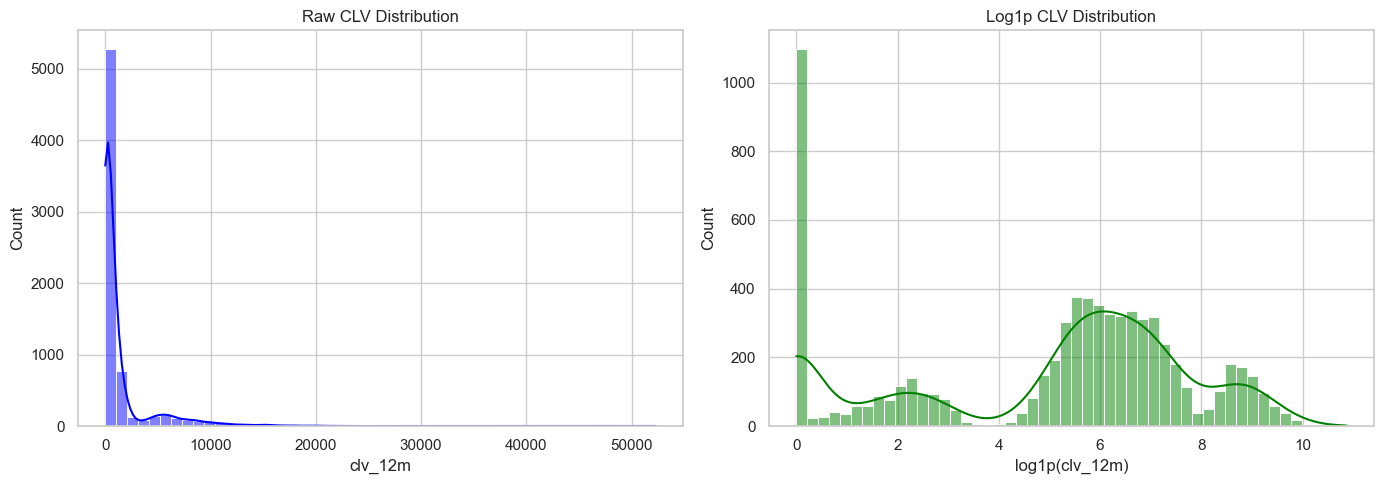

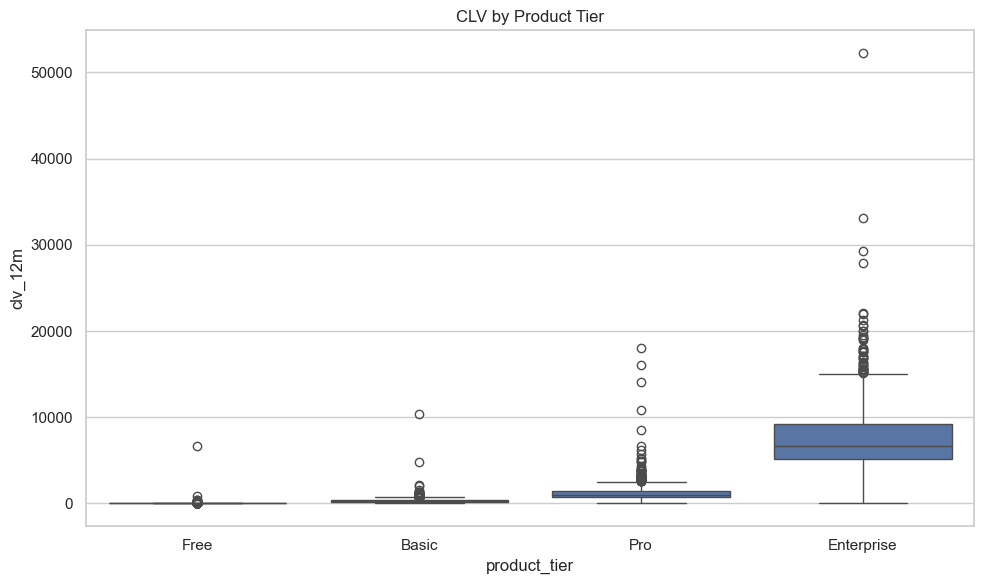

In [52]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["clv_12m"], bins=50, kde=True, ax=axes[0], color="blue")
axes[0].set_title("Raw CLV Distribution")
axes[0].set_xlabel("clv_12m")

sns.histplot(np.log1p(df["clv_12m"]), bins=50, kde=True, ax=axes[1], color="green")
axes[1].set_title("Log1p CLV Distribution")
axes[1].set_xlabel("log1p(clv_12m)")

plt.tight_layout()
plt.savefig("../reports/clv_distribution.png")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="product_tier", y="clv_12m", order=["Free", "Basic", "Pro", "Enterprise"])
plt.title("CLV by Product Tier")
plt.tight_layout()
plt.savefig("../reports/clv_by_product_tier.png")
plt.show()

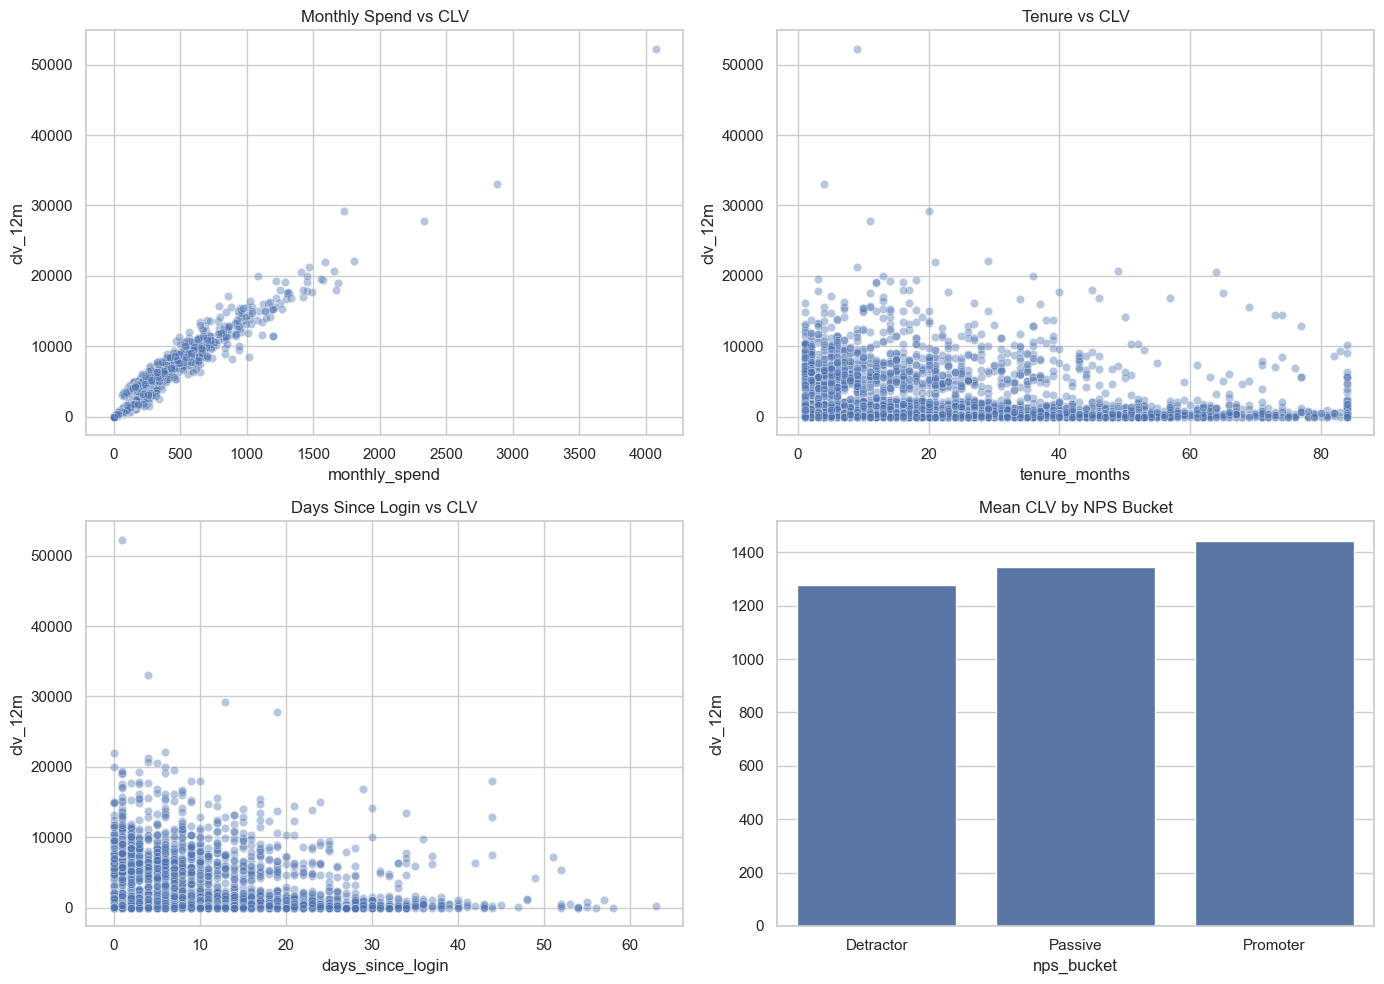

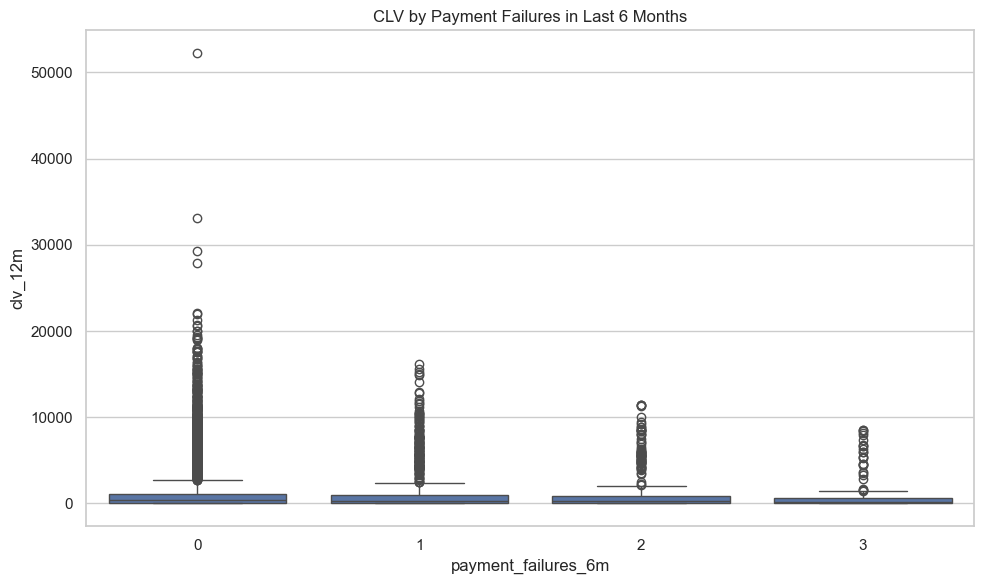

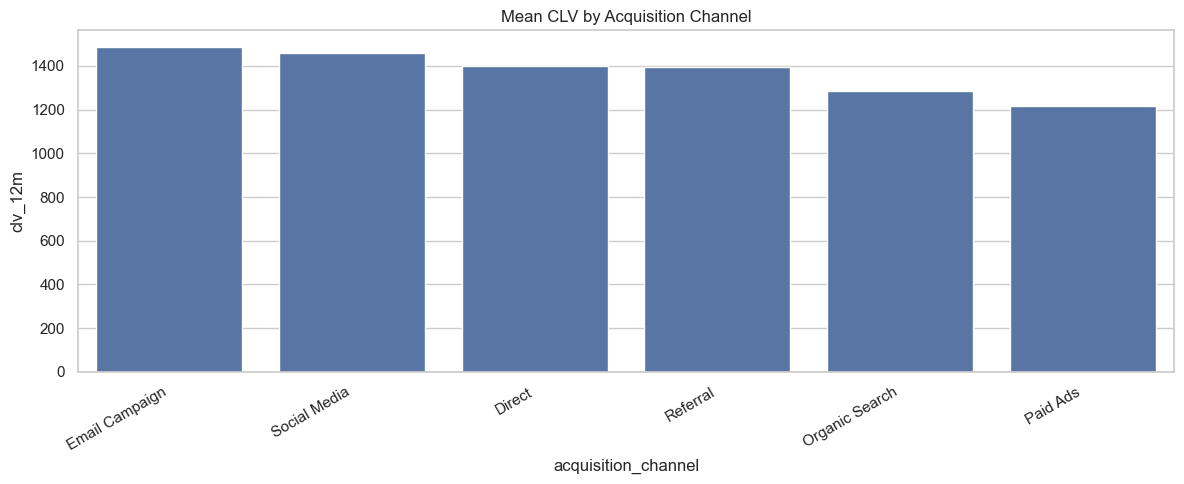

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df, x="monthly_spend", y="clv_12m", alpha=0.4, ax=axes[0, 0])
axes[0, 0].set_title("Monthly Spend vs CLV")

sns.scatterplot(data=df, x="tenure_months", y="clv_12m", alpha=0.4, ax=axes[0, 1])
axes[0, 1].set_title("Tenure vs CLV")

sns.scatterplot(data=df, x="days_since_login", y="clv_12m", alpha=0.4, ax=axes[1, 0])
axes[1, 0].set_title("Days Since Login vs CLV")

nps_bucket = pd.cut(df["nps_score"], bins=[-np.inf, 6, 8, np.inf], labels=["Detractor", "Passive", "Promoter"])
temp = df.assign(nps_bucket=nps_bucket)
sns.barplot(data=temp, x="nps_bucket", y="clv_12m", order=["Detractor", "Passive", "Promoter"], estimator=np.mean, errorbar=None, ax=axes[1, 1])
axes[1, 1].set_title("Mean CLV by NPS Bucket")

plt.tight_layout()
plt.savefig("../reports/clv_scatterplots.png")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="payment_failures_6m", y="clv_12m")
plt.title("CLV by Payment Failures in Last 6 Months")
plt.tight_layout()
plt.savefig("../reports/clv_by_payment_failures.png")
plt.show()

plt.figure(figsize=(12, 5))
channel_means = df.groupby("acquisition_channel", as_index=False)["clv_12m"].mean().sort_values("clv_12m", ascending=False)
sns.barplot(data=channel_means, x="acquisition_channel", y="clv_12m", color="#4c72b0")
plt.xticks(rotation=30, ha="right")
plt.title("Mean CLV by Acquisition Channel")
plt.tight_layout()
plt.savefig("../reports/clv_by_acquisition_channel.png")
plt.show()

Random feedback samples:
1. not worth the price... the competitor offers more for less...
2. frustrated with constant login issues. starting to look at alternatives.
3. Had 9 support tickets in the last few months and issues are still open.
4. Great product. The new features they added last quarter are excellent.
5. some features are behind a paywall that feels excessive.
6. Had 2 support tickets in the last few months and issues are still open.
7. love this product. it has completely changed how i manage my finances.
8. Had 7 support tickets in the last few months and issues are still open.
9. Customer service was polite but couldn't fix my problem on the first try.
10. It's fine. Does what it says, nothing special.


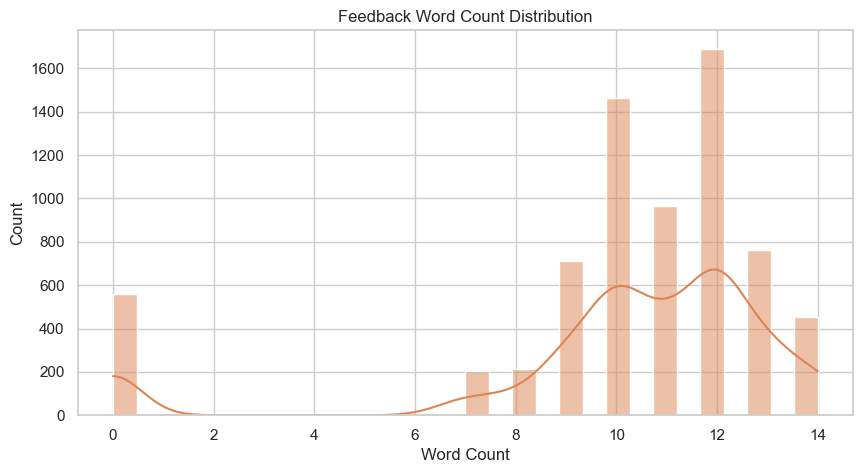


Top positive words:
[('the', 1347), ('and', 863), ('for', 321), ('was', 302), ('team', 278), ('product', 273), ('pro', 224), ('plan', 224), ('last', 222), ('support', 219), ('what', 219), ('this', 219), ('every', 217), ('months', 213), ('better', 208)]

Top negative words:
[('the', 668), ('and', 586), ('for', 550), ('competitor', 289), ('months', 286), ('issues', 286), ('last', 284), ('not', 276), ('support', 273), ('what', 268), ('too', 257), ('poor', 158), ('customer', 158), ('service', 158), ('was', 158)]


In [56]:
sample_feedback = df["customer_feedback"].dropna().sample(10, random_state=42)
print("Random feedback samples:")
for i, text in enumerate(sample_feedback, 1):
    print(f"{i}. {text}")

df["feedback_word_count"] = df["customer_feedback"].fillna("").apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df["feedback_word_count"], bins=30, kde=True, color="#dd8452")
plt.title("Feedback Word Count Distribution")
plt.xlabel("Word Count")
plt.show()

def tokenize(text):
    return re.findall(r"\b[a-z]{3,}\b", str(text).lower())

positive_words = Counter()
negative_words = Counter()

positive_mask = df["nps_score"] >= 9
negative_mask = df["nps_score"] <= 4

for text in df.loc[positive_mask, "customer_feedback"].dropna():
    positive_words.update(tokenize(text))

for text in df.loc[negative_mask, "customer_feedback"].dropna():
    negative_words.update(tokenize(text))

print("\nTop positive words:")
print(positive_words.most_common(15))

print("\nTop negative words:")
print(negative_words.most_common(15))

In [58]:
df['nps_score'].sample(5, random_state=42)

2476    8.0
6769    9.0
4635    5.0
3047    8.0
4092    2.0
Name: nps_score, dtype: float64

In [59]:
valid_tiers = {"Free", "Basic", "Pro", "Enterprise"}
valid_channels = {"Organic Search", "Paid Ads", "Referral", "Social Media", "Email Campaign", "Direct"}

tiers_now = set(df["product_tier"].dropna().unique())
channels_now = set(df["acquisition_channel"].dropna().unique())

invalid_tiers = sorted(tiers_now - valid_tiers)
invalid_channels = sorted(channels_now - valid_channels)

print("Invalid product_tier values:", invalid_tiers)
print("Invalid acquisition_channel values:", invalid_channels)

print("\nCurrent product_tier values:", sorted(tiers_now))
print("Current acquisition_channel values:", sorted(channels_now))

assert len(invalid_tiers) == 0, "Unexpected values found in product_tier"
assert len(invalid_channels) == 0, "Unexpected values found in acquisition_channel"
print("\nCategorical consistency check passed.")

Invalid product_tier values: []
Invalid acquisition_channel values: []

Current product_tier values: ['Basic', 'Enterprise', 'Free', 'Pro']
Current acquisition_channel values: ['Direct', 'Email Campaign', 'Organic Search', 'Paid Ads', 'Referral', 'Social Media']

Categorical consistency check passed.


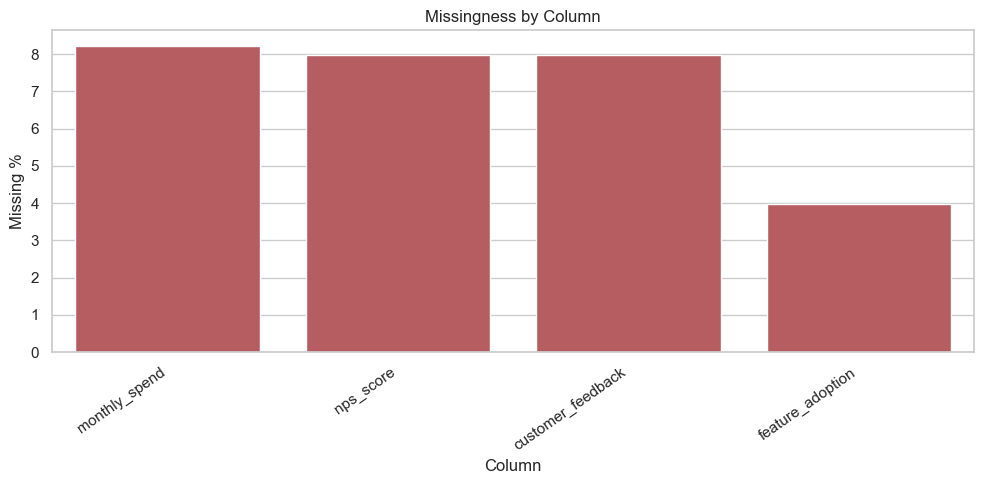

In [60]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_df = missing_pct[missing_pct > 0].reset_index()
missing_df.columns = ["column", "missing_pct"]

plt.figure(figsize=(10, 5))
sns.barplot(data=missing_df, x="column", y="missing_pct", color="#c44e52")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Missing %")
plt.xlabel("Column")
plt.title("Missingness by Column")
plt.tight_layout()
plt.savefig("../reports/missingness_by_column.png")
plt.show()

## EDA Findings Summary

- CLV target is strongly right-skewed; log1p transformation is justified for modeling stability.
- Product tier is the strongest separator of CLV, with clear ordering Free < Basic < Pro < Enterprise.
- Behavioral signals align with CLV expectations: higher monthly spend and longer tenure generally map to higher CLV, while more days since login and payment failures map to lower CLV.
- NPS buckets show directional signal, with promoters having higher mean CLV than detractors.
- Text exploration shows distinct positive versus negative vocabularies, supporting the value of downstream NLP features.
- Categorical normalization checks passed for product_tier and acquisition_channel.